In [1]:
!pip install pandas numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 33.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 51.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 29.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 44.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 54.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib]3 [matplotlib]n]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Accuracy: 0.6364
ROC AUC: 0.6615
              precision    recall  f1-score   support

           0       0.34      0.35      0.34        66
           1       0.75      0.74      0.75       176

    accuracy                           0.64       242
   macro avg       0.55      0.55      0.55       242
weighted avg       0.64      0.64      0.64       242



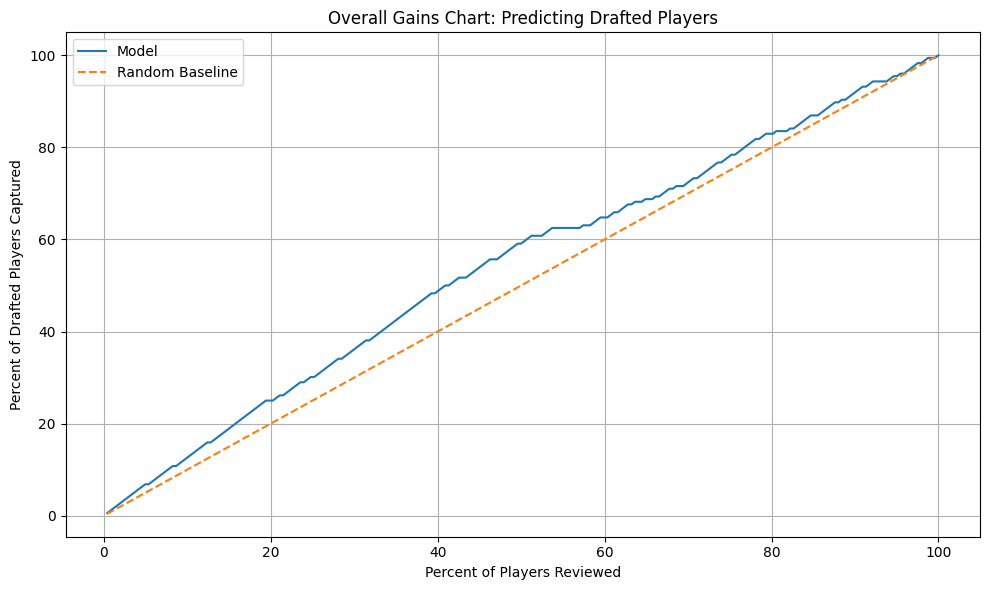

Saved: overall_gains_chart_output_no_log_rank.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)


# =========================
# 2. CLEAN POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill",
    "RB": "Skill",
    "FB": "Skill",
    "WR": "Skill",
    "TE": "Skill",

    "OT": "OL",
    "OG": "OL",
    "G": "OL",
    "C": "OL",
    "OC": "OL",
    "IOL": "OL",
    "OL": "OL",

    "EDGE": "DL",
    "DE": "DL",
    "DT": "DL",
    "DL": "DL",

    "LB": "LB",
    "ILB": "LB",
    "OLB": "LB",

    "CB": "Secondary",
    "S": "Secondary",
    "SAF": "Secondary",
    "DB": "Secondary",

    "K": "Special Teams",
    "P": "Special Teams",
    "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. TARGET VARIABLE
# =========================

df["Drafted"] = np.where(df["Overall Pick"] < 300, 1, 0)


# =========================
# 4. FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Drafted"]


categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]


# =========================
# 5. MODEL PIPELINE
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=5
        ))
    ]
)


# =========================
# 6. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)


# =========================
# 7. MODEL RESULTS
# =========================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print(classification_report(y_test, y_pred))


# =========================
# 8. GAINS CHART DATA
# =========================

gains_df = X_test.copy()
gains_df["Actual"] = y_test.values
gains_df["Predicted Probability"] = y_prob


# =========================
# 9. OVERALL GAINS CHART ONLY
# =========================

overall_gains = gains_df.sort_values(
    by="Predicted Probability",
    ascending=False
).reset_index(drop=True)

overall_gains["Cumulative Drafted"] = overall_gains["Actual"].cumsum()
total_drafted = overall_gains["Actual"].sum()

overall_gains["Percent of Players Reviewed"] = (
    np.arange(1, len(overall_gains) + 1) / len(overall_gains)
) * 100

overall_gains["Percent of Drafted Players Captured"] = (
    overall_gains["Cumulative Drafted"] / total_drafted
) * 100

plt.figure(figsize=(10, 6))

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Drafted Players Captured"],
    label="Model"
)

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Players Reviewed"],
    linestyle="--",
    label="Random Baseline"
)

plt.title("Overall Gains Chart: Predicting Drafted Players")
plt.xlabel("Percent of Players Reviewed")
plt.ylabel("Percent of Drafted Players Captured")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 10. SAVE OUTPUT
# =========================

gains_df.to_csv("overall_gains_chart_output_no_log_rank.csv", index=False)

print("Saved: overall_gains_chart_output_no_log_rank.csv")

Dataset shape: (965, 27)

Draft Round Counts:
Draft Round
Undrafted    264
Round 6      156
Round 2       96
Round 1       96
Round 4       94
Round 3       93
Round 5       92
Round 7       74
Name: count, dtype: int64



5-Fold Stratified Cross-Validation Accuracy Scores:
[0.2642487  0.22279793 0.20725389 0.22279793 0.2642487 ]

Average CV Accuracy:
0.2363

CV Accuracy Standard Deviation:
0.0235

Test Set Accuracy:
0.2397

Full Classification Report:
Class          Precision      Recall    F1-Score     Support
Round 1             0.38        0.62        0.47          24
Round 2             0.08        0.04        0.06          24
Round 3             0.06        0.04        0.05          23
Round 4             0.11        0.08        0.09          24
Round 5             0.24        0.35        0.29          23
Round 6             0.13        0.08        0.10          39
Round 7             0.00        0.00        0.00          19
Undrafted           0.36        0.42        0.39          66

Overall Accuracy: 0.2397

Creating gains chart for: Round 1


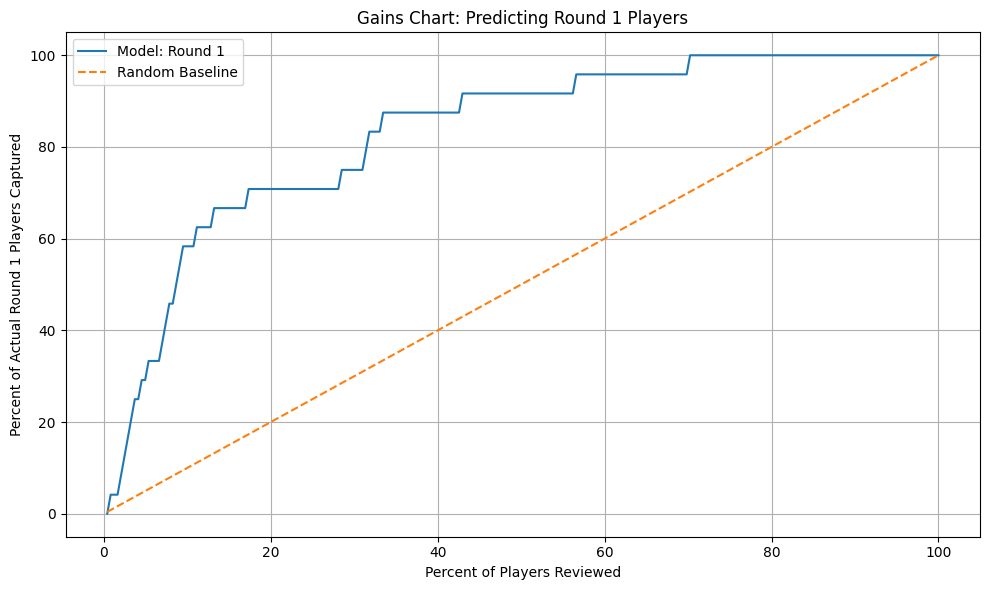


Creating gains chart for: Round 2


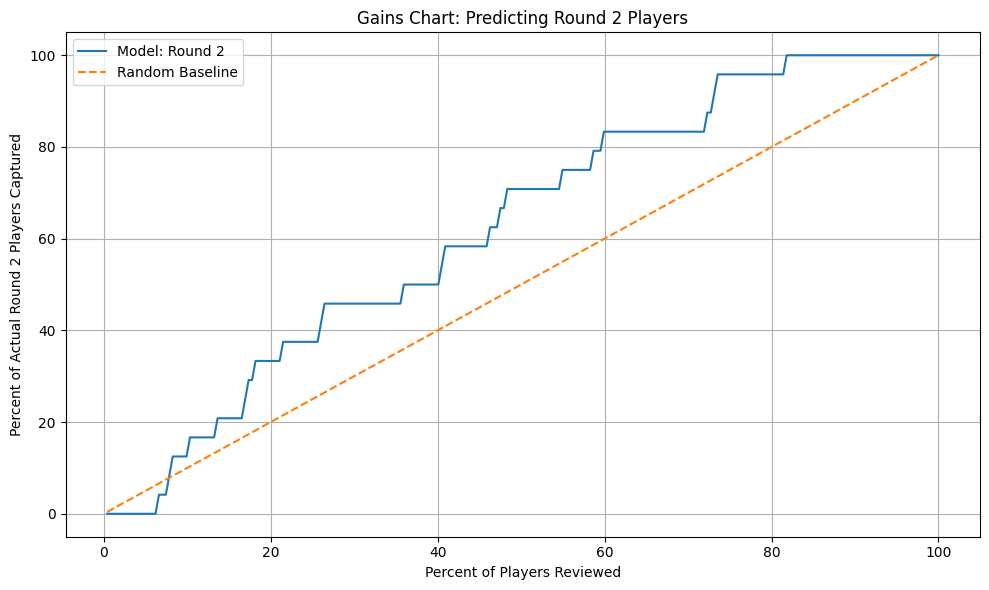


Creating gains chart for: Round 3


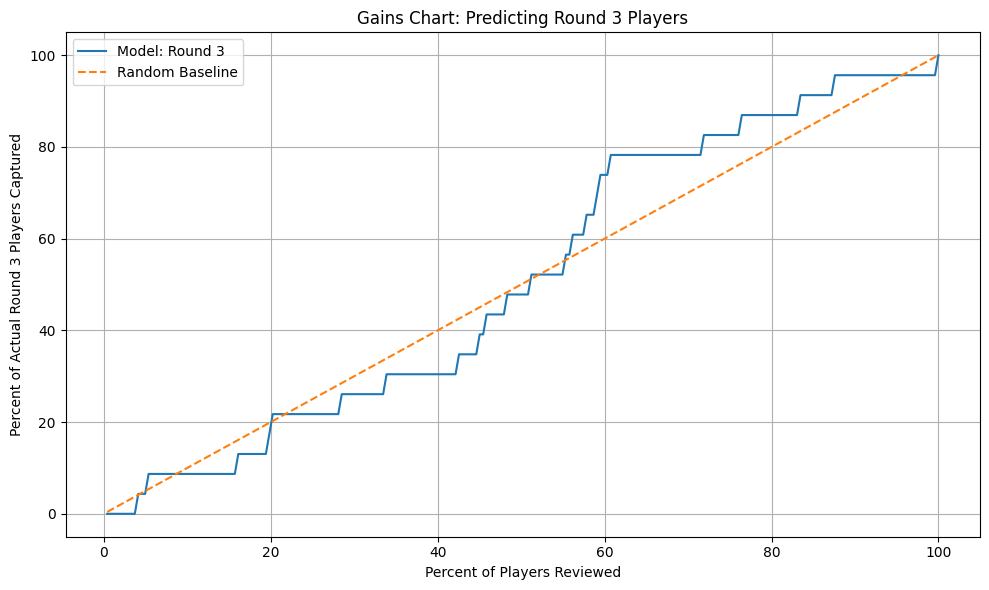


Creating gains chart for: Round 4


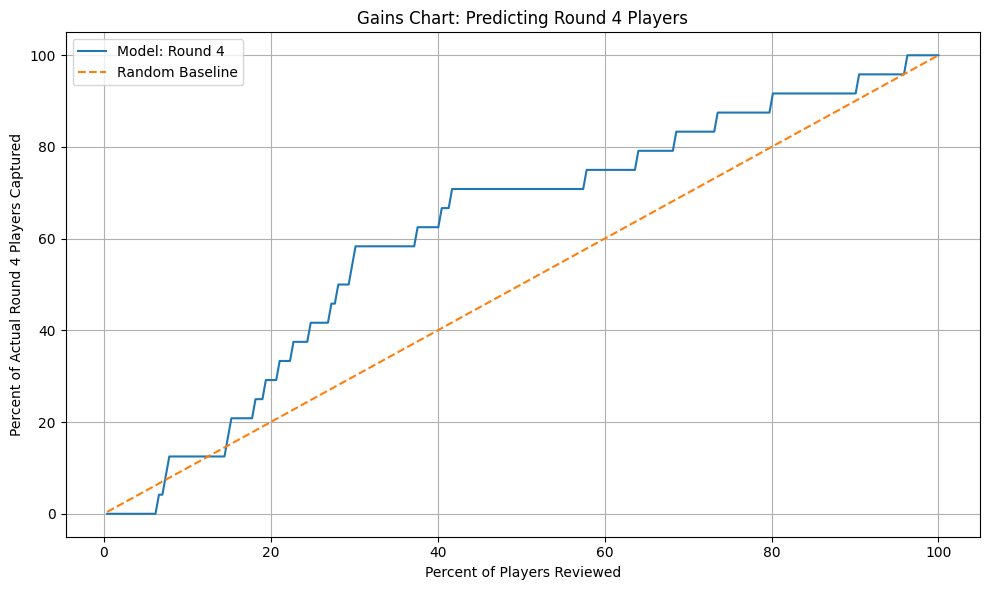


Creating gains chart for: Round 5


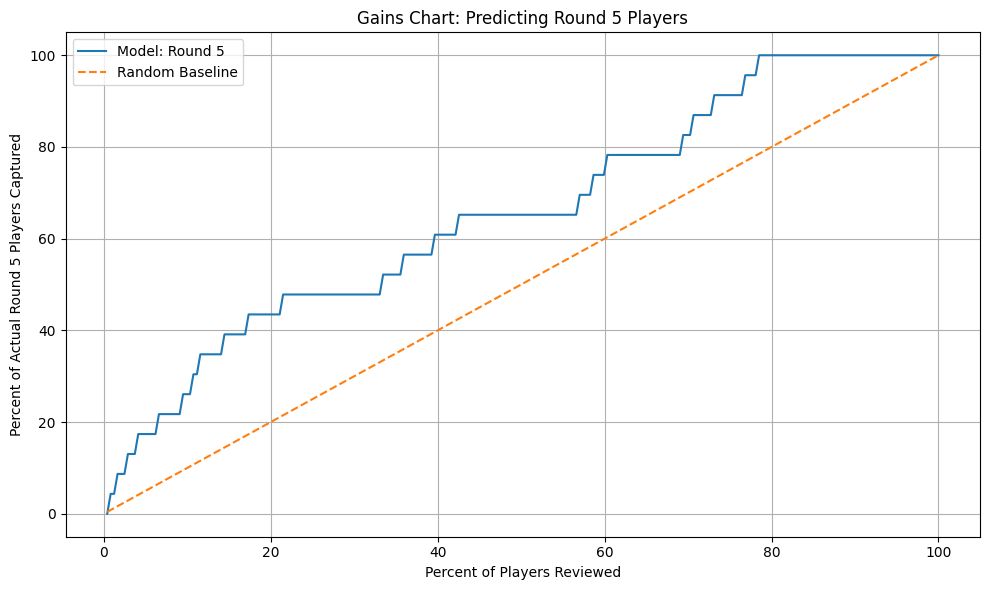


Creating gains chart for: Round 6


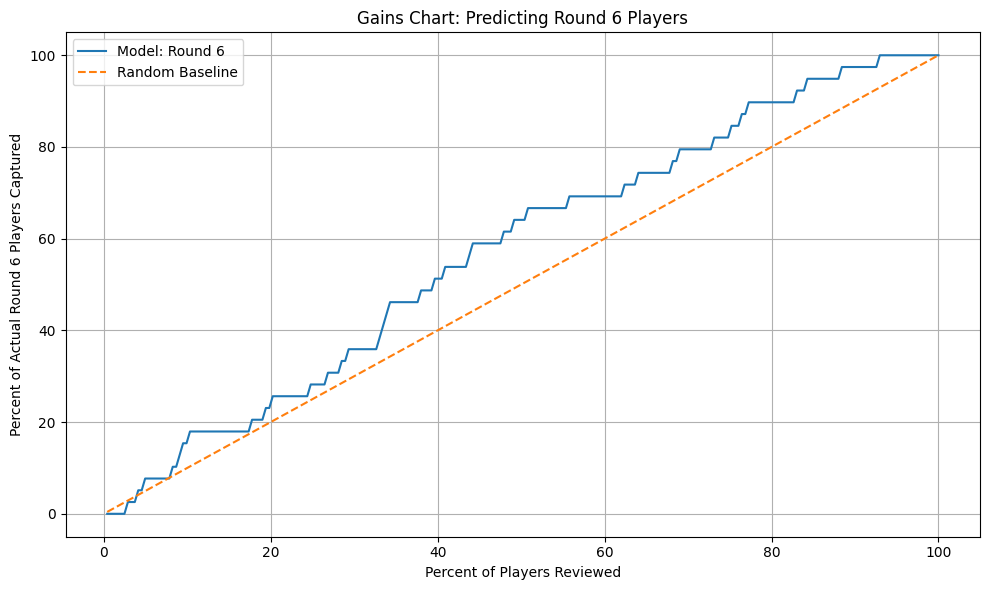


Creating gains chart for: Round 7


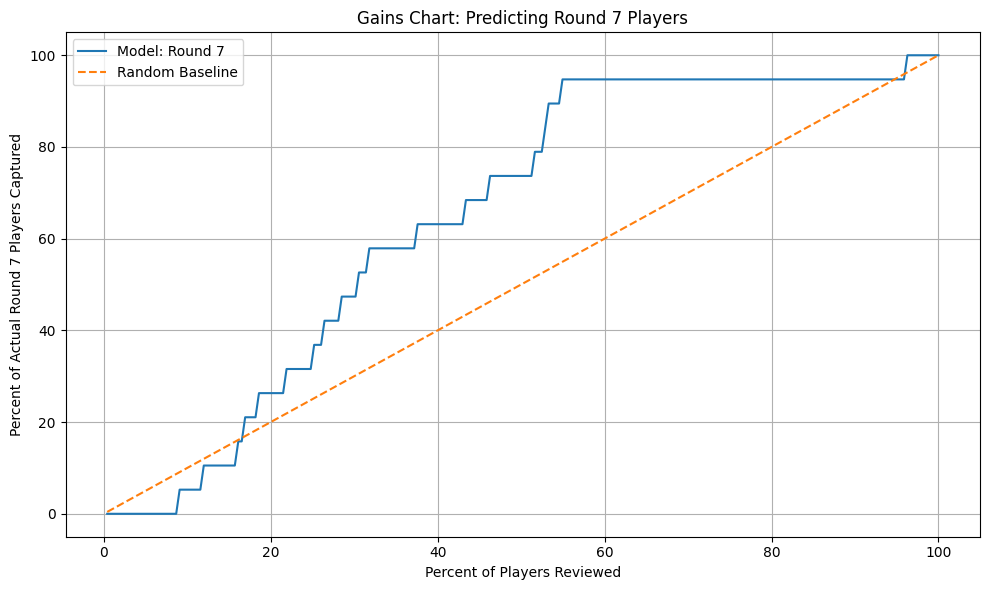


Creating gains chart for: Undrafted


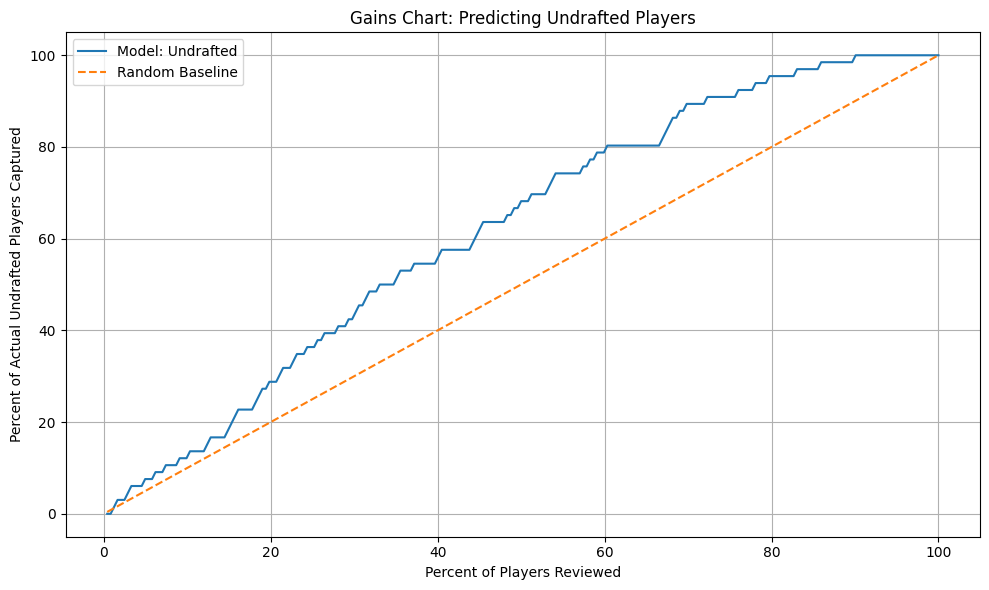


Done. Gains chart CSV files saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT ROUND TARGET
# =========================

def draft_round(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 64:
        return "Round 2"
    elif pick <= 96:
        return "Round 3"
    elif pick <= 128:
        return "Round 4"
    elif pick <= 160:
        return "Round 5"
    elif pick <= 224:
        return "Round 6"
    elif pick <= 262:
        return "Round 7"
    else:
        return "Undrafted"

df["Draft Round"] = df["Overall Pick"].apply(draft_round)

print("\nDraft Round Counts:")
print(df["Draft Round"].value_counts())


# =========================
# 4. SELECT FEATURES
# =========================
# Log Rank is intentionally removed.

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Draft Round"]


# =========================
# 5. PREPROCESSING
# =========================

categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


# =========================
# 6. RANDOM FOREST MODEL
# =========================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=5
        ))
    ]
)


# =========================
# 7. 5-FOLD STRATIFIED CROSS-VALIDATION
# =========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n5-Fold Stratified Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:")
print(round(cv_scores.mean(), 4))

print("\nCV Accuracy Standard Deviation:")
print(round(cv_scores.std(), 4))


# =========================
# 8. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)


# =========================
# 9. TEST SET PERFORMANCE
# =========================

y_pred = model.predict(X_test)

labels_order = [
    "Round 1",
    "Round 2",
    "Round 3",
    "Round 4",
    "Round 5",
    "Round 6",
    "Round 7",
    "Undrafted"
]

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=labels_order,
    zero_division=0
)

print("\nTest Set Accuracy:")
print(round(accuracy_score(y_test, y_pred), 4))

print("\nFull Classification Report:")
print(f"{'Class':<12}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
    print(f"{label:<12}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

print("\nOverall Accuracy:", round(accuracy_score(y_test, y_pred), 4))


# =========================
# 10. PREDICT PROBABILITIES
# =========================

predicted_probs = model.predict_proba(X_test)
class_labels = model.named_steps["classifier"].classes_

prob_df = pd.DataFrame(
    predicted_probs,
    columns=class_labels
)

gains_base = X_test.copy().reset_index(drop=True)
gains_base["Actual Draft Round"] = y_test.reset_index(drop=True)


# =========================
# 11. FUNCTION TO CREATE GAINS CHART
# =========================

def plot_gains_chart(target_round):
    temp_df = gains_base.copy()

    temp_df["Actual Target"] = np.where(
        temp_df["Actual Draft Round"] == target_round,
        1,
        0
    )

    temp_df["Predicted Probability"] = prob_df[target_round].values

    temp_df = temp_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    total_actual_targets = temp_df["Actual Target"].sum()

    if total_actual_targets == 0:
        print(f"No actual {target_round} players in the test set.")
        return None

    temp_df["Cumulative Actual Captured"] = temp_df["Actual Target"].cumsum()

    temp_df["Percent of Players Reviewed"] = (
        np.arange(1, len(temp_df) + 1) / len(temp_df)
    ) * 100

    temp_df["Percent of Actual Round Captured"] = (
        temp_df["Cumulative Actual Captured"] / total_actual_targets
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Actual Round Captured"],
        label=f"Model: {target_round}"
    )

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"Gains Chart: Predicting {target_round} Players")
    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_round} Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return temp_df


# =========================
# 12. CREATE GAINS CHARTS FOR EACH ROUND
# =========================

round_outputs = {}

for draft_class in labels_order:
    print(f"\nCreating gains chart for: {draft_class}")
    round_outputs[draft_class] = plot_gains_chart(draft_class)


# =========================
# 13. SAVE GAINS CHART DATA
# =========================

for draft_class, output_df in round_outputs.items():
    if output_df is not None:
        clean_name = (
            draft_class.replace(" ", "_")
                       .replace("-", "_")
                       .replace("/", "_")
        )

        output_df.to_csv(
            f"gains_chart_{clean_name}_no_log_rank.csv",
            index=False
        )

print("\nDone. Gains chart CSV files saved.")

Dataset shape: (965, 27)

Draft Tier Counts:
Draft Tier
Undrafted     264
Rounds 6-7    230
Rounds 2-3    189
Rounds 4-5    186
Round 1        96
Name: count, dtype: int64



OVERALL MODEL - 5-Fold CV Accuracy Scores:
[0.27979275 0.30051813 0.2746114  0.29533679 0.27979275]
Average CV Accuracy: 0.286
CV Accuracy Standard Deviation: 0.01

OVERALL MODEL - Classification Report
Class            Precision      Recall    F1-Score     Support
Round 1               0.36        0.71        0.48          24
Rounds 2-3            0.14        0.09        0.11          47
Rounds 4-5            0.18        0.19        0.19          47
Rounds 6-7            0.21        0.12        0.15          58
Undrafted             0.43        0.55        0.48          66

Accuracy: 0.3017

Top 20 Overall Features:
                       Feature  Importance
           num__National Award    0.077663
                      num__FPI    0.054675
   num__40-Yard Dash (seconds)    0.051482
     num__Efficiencies Overall    0.050627
                      num__ELO    0.050055
      num__Broad Jump (inches)    0.048301
        num__Wingspan (inches)    0.047243
             num__Arm (inches)

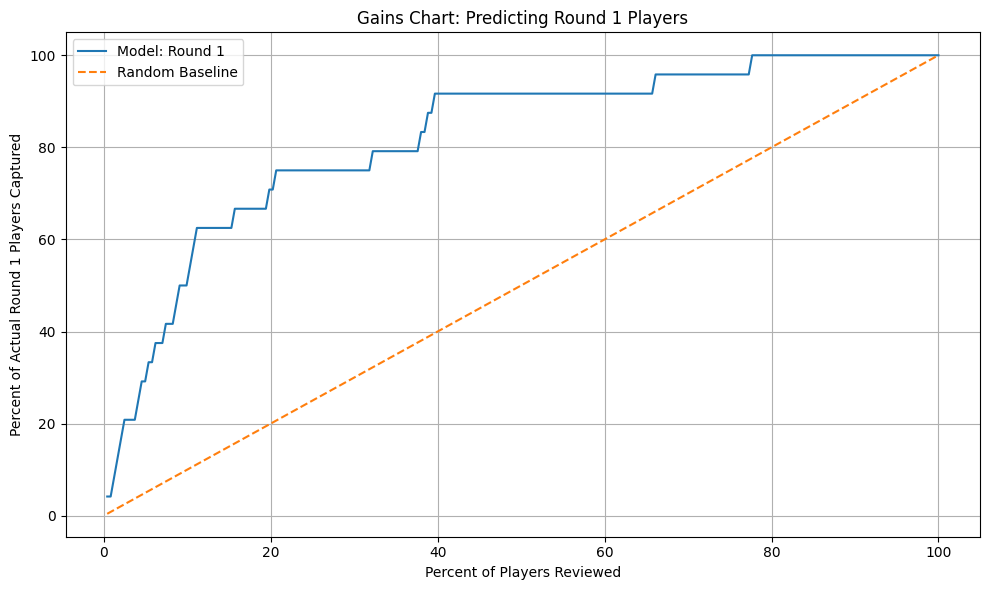


Creating gains chart for: Rounds 2-3


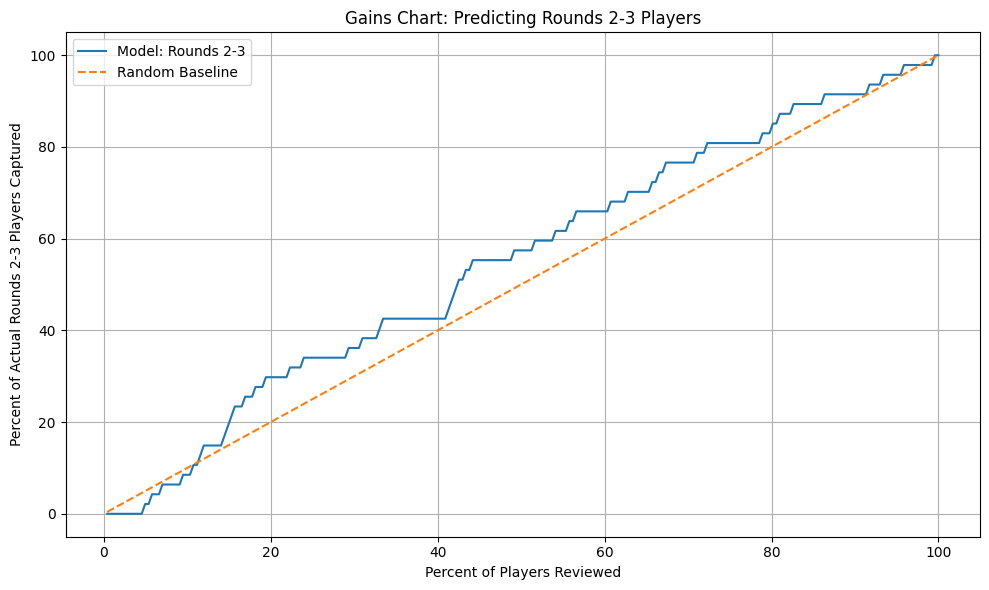


Creating gains chart for: Rounds 4-5


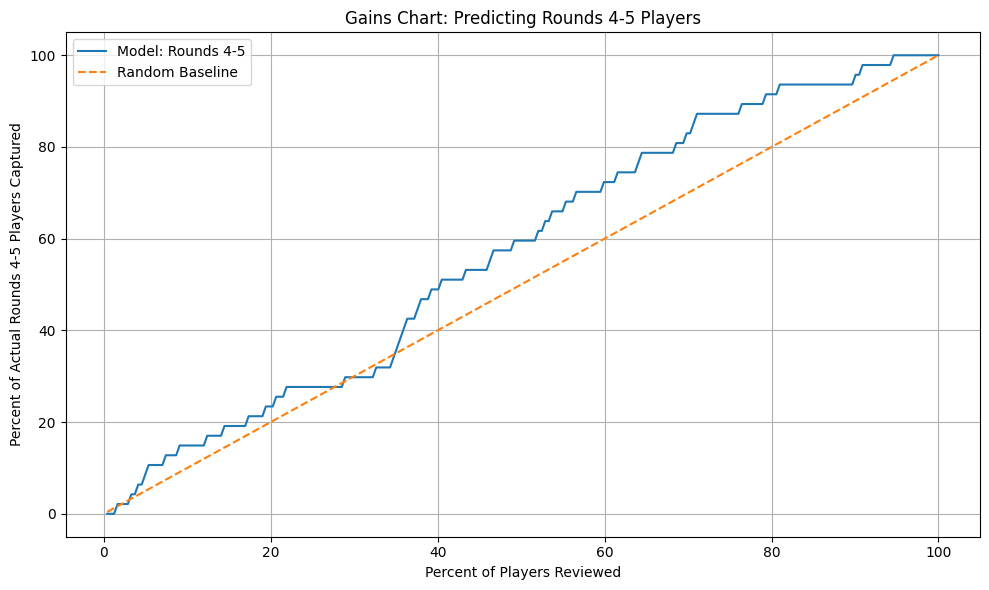


Creating gains chart for: Rounds 6-7


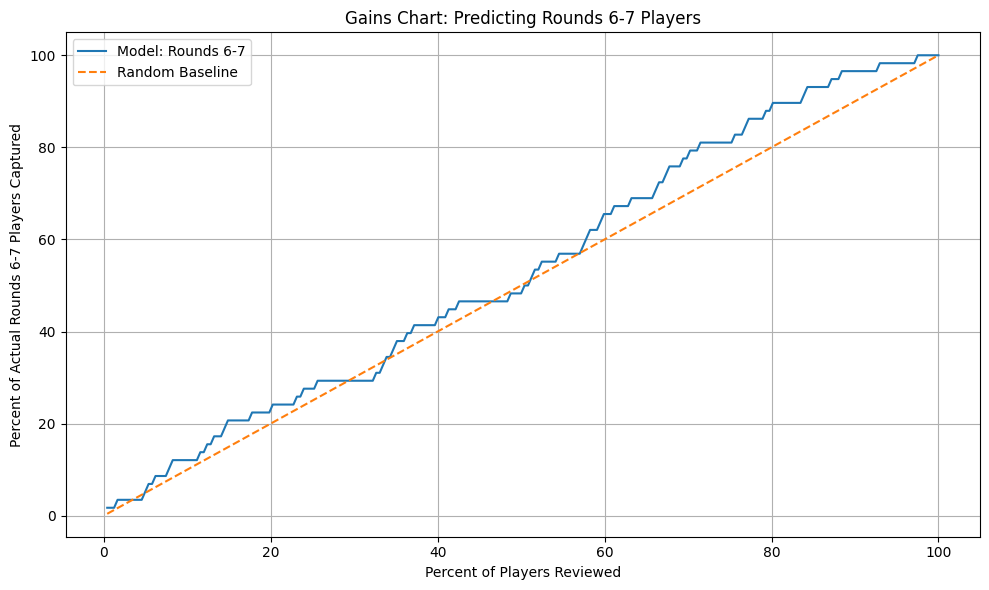


Creating gains chart for: Undrafted


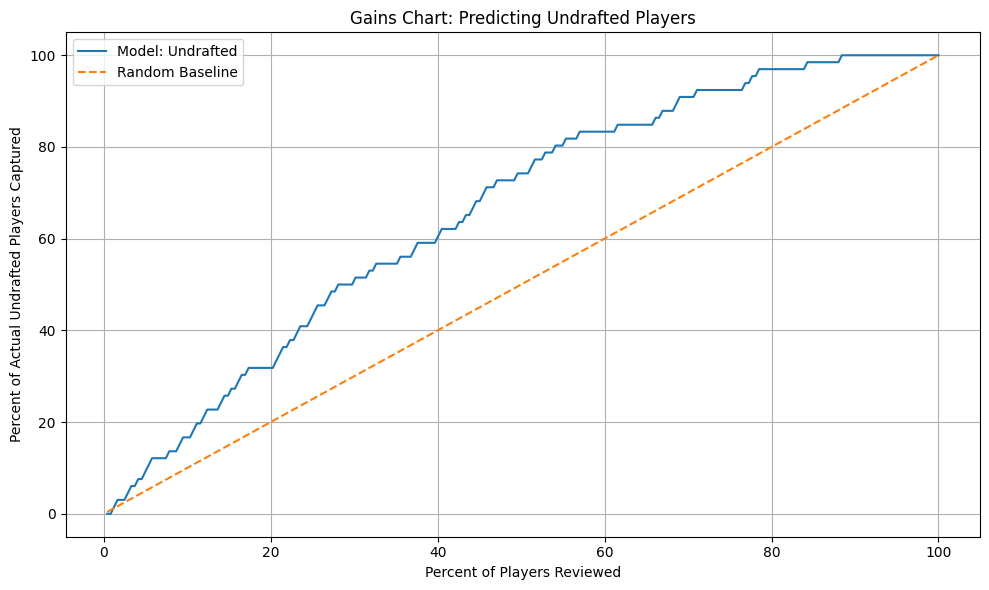


Done. Position group models, feature importance tables, and gains charts saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT TIER TARGET
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# =========================
# Log Rank removed.

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]

combine_metrics = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]


# =========================
# 5. BUILD MODEL FUNCTION
# =========================

def build_model(feature_list):
    categorical_features = [
        col for col in ["Position", "Position Group", "School", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced",
                min_samples_leaf=5
            ))
        ]
    )

    return model


# =========================
# 6. MANUAL CLASSIFICATION REPORT
# =========================

def print_manual_report(y_true, y_pred, title):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels_order,
        zero_division=0
    )

    print(f"\n{title}")
    print(f"{'Class':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    print("\nAccuracy:", round(accuracy_score(y_true, y_pred), 4))


# =========================
# 7. OVERALL MODEL
# =========================

X = df[features]
y = df["Draft Tier"]

overall_model = build_model(features)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    overall_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nOVERALL MODEL - 5-Fold CV Accuracy Scores:")
print(cv_scores)
print("Average CV Accuracy:", round(cv_scores.mean(), 4))
print("CV Accuracy Standard Deviation:", round(cv_scores.std(), 4))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

overall_model.fit(X_train, y_train)
y_pred = overall_model.predict(X_test)

print_manual_report(
    y_test,
    y_pred,
    "OVERALL MODEL - Classification Report"
)


# =========================
# 8. OVERALL FEATURE IMPORTANCE
# =========================

rf = overall_model.named_steps["classifier"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Overall Features:")
print(importance_df.head(20).to_string(index=False))


# =========================
# 9. POSITION GROUP MODELS
# =========================
# Separate models allow combine metrics to matter differently by position group.

position_group_results = []
position_group_importances = []

for group in df["Position Group"].dropna().unique():
    group_df = df[df["Position Group"] == group].copy()

    print("\n" + "=" * 70)
    print(f"POSITION GROUP MODEL: {group}")
    print("=" * 70)
    print("Rows:", len(group_df))
    print("Draft Tier Counts:")
    print(group_df["Draft Tier"].value_counts())

    if len(group_df) < 50 or group_df["Draft Tier"].nunique() < 2:
        print("Skipped: not enough data or only one draft tier present.")
        continue

    group_features = [
        col for col in features if col != "Position Group"
    ]

    X_group = group_df[group_features]
    y_group = group_df["Draft Tier"]

    min_class_count = y_group.value_counts().min()

    if min_class_count < 2:
        print("Skipped: at least one class has fewer than 2 players.")
        continue

    n_splits = min(5, min_class_count)

    group_model = build_model(group_features)

    group_cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    group_cv_scores = cross_val_score(
        group_model,
        X_group,
        y_group,
        cv=group_cv,
        scoring="accuracy"
    )

    print(f"\n{n_splits}-Fold Stratified CV Accuracy Scores:")
    print(group_cv_scores)
    print("Average CV Accuracy:", round(group_cv_scores.mean(), 4))
    print("CV Accuracy Standard Deviation:", round(group_cv_scores.std(), 4))

    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_group,
        y_group,
        test_size=0.25,
        random_state=42,
        stratify=y_group
    )

    group_model.fit(X_train_g, y_train_g)
    y_pred_g = group_model.predict(X_test_g)

    print_manual_report(
        y_test_g,
        y_pred_g,
        f"{group} - Classification Report"
    )

    position_group_results.append({
        "Position Group": group,
        "Rows": len(group_df),
        "CV Accuracy Mean": group_cv_scores.mean(),
        "CV Accuracy Std": group_cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test_g, y_pred_g)
    })

    rf_g = group_model.named_steps["classifier"]
    feature_names_g = group_model.named_steps["preprocessor"].get_feature_names_out()

    importance_g = pd.DataFrame({
        "Feature": feature_names_g,
        "Importance": rf_g.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"\nTop 15 Features for {group}:")
    print(importance_g.head(15).to_string(index=False))

    combine_group_importance = []

    for metric in combine_metrics:
        matching_rows = importance_g[
            importance_g["Feature"].str.contains(metric, regex=False)
        ]

        combine_group_importance.append({
            "Position Group": group,
            "Metric": metric,
            "Importance": matching_rows["Importance"].sum()
        })

    combine_group_df = pd.DataFrame(combine_group_importance).sort_values(
        by="Importance",
        ascending=False
    )

    print(f"\nCombine Metric Importance for {group}:")
    print(combine_group_df.to_string(index=False))

    position_group_importances.append(combine_group_df)


# =========================
# 10. SAVE POSITION GROUP SUMMARY
# =========================

position_group_results_df = pd.DataFrame(position_group_results)

print("\nPOSITION GROUP MODEL SUMMARY:")
print(position_group_results_df.to_string(index=False))

position_group_results_df.to_csv(
    "position_group_model_summary_no_log_rank.csv",
    index=False
)

if position_group_importances:
    all_position_importances_df = pd.concat(
        position_group_importances,
        ignore_index=True
    )

    all_position_importances_df.to_csv(
        "position_group_combine_metric_importance_no_log_rank.csv",
        index=False
    )


# =========================
# 11. GAINS CHARTS FOR OVERALL MODEL ONLY
# =========================

predicted_probs = overall_model.predict_proba(X_test)
class_labels = overall_model.named_steps["classifier"].classes_

prob_df = pd.DataFrame(
    predicted_probs,
    columns=class_labels
)

gains_base = X_test.copy().reset_index(drop=True)
gains_base["Actual Draft Tier"] = y_test.reset_index(drop=True)


def plot_gains_chart(target_tier):
    temp_df = gains_base.copy()

    temp_df["Actual Target"] = np.where(
        temp_df["Actual Draft Tier"] == target_tier,
        1,
        0
    )

    temp_df["Predicted Probability"] = prob_df[target_tier].values

    temp_df = temp_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    total_actual_targets = temp_df["Actual Target"].sum()

    if total_actual_targets == 0:
        print(f"No actual {target_tier} players in the test set.")
        return None

    temp_df["Cumulative Actual Captured"] = temp_df["Actual Target"].cumsum()

    temp_df["Percent of Players Reviewed"] = (
        np.arange(1, len(temp_df) + 1) / len(temp_df)
    ) * 100

    temp_df["Percent of Actual Tier Captured"] = (
        temp_df["Cumulative Actual Captured"] / total_actual_targets
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Actual Tier Captured"],
        label=f"Model: {target_tier}"
    )

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"Gains Chart: Predicting {target_tier} Players")
    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_tier} Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return temp_df


tier_outputs = {}

for tier in labels_order:
    print(f"\nCreating gains chart for: {tier}")
    tier_outputs[tier] = plot_gains_chart(tier)

for tier, output_df in tier_outputs.items():
    if output_df is not None:
        clean_name = (
            tier.replace(" ", "_")
                .replace("-", "_")
                .replace("/", "_")
        )

        output_df.to_csv(
            f"gains_chart_{clean_name}_no_log_rank.csv",
            index=False
        )

print("\nDone. Position group models, feature importance tables, and gains charts saved.")

In [11]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 44.6 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 40.2 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



XGBoost Results:
Accuracy: 0.7149
ROC AUC: 0.6524

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.23      0.30        66
           1       0.76      0.90      0.82       176

    accuracy                           0.71       242
   macro avg       0.61      0.56      0.56       242
weighted avg       0.67      0.71      0.68       242



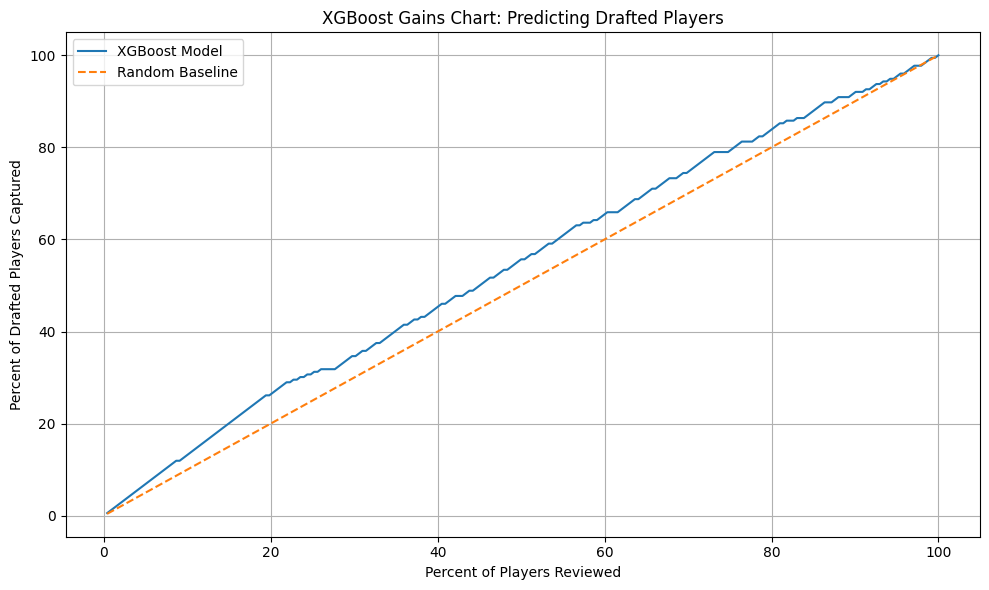


Saved: xgboost_gains_chart_output.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)


# =========================
# 2. CLEAN POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill",
    "RB": "Skill",
    "FB": "Skill",
    "WR": "Skill",
    "TE": "Skill",

    "OT": "OL",
    "OG": "OL",
    "G": "OL",
    "C": "OL",
    "OC": "OL",
    "IOL": "OL",
    "OL": "OL",

    "EDGE": "DL",
    "DE": "DL",
    "DT": "DL",
    "DL": "DL",

    "LB": "LB",
    "ILB": "LB",
    "OLB": "LB",

    "CB": "Secondary",
    "S": "Secondary",
    "SAF": "Secondary",
    "DB": "Secondary",

    "K": "Special Teams",
    "P": "Special Teams",
    "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. TARGET VARIABLE
# =========================

df["Drafted"] = np.where(df["Overall Pick"] < 300, 1, 0)


# =========================
# 4. FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "3-Cone (seconds)",
    "Combine Participation",
    "ELO",
    "Efficiencies Overall",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Drafted"]


# =========================
# 5. CATEGORICAL / NUMERIC
# =========================

categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]


# =========================
# 6. PREPROCESSING
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)


# =========================
# 7. XGBOOST MODEL
# =========================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)


# =========================
# 8. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# =========================
# 9. FIT MODEL
# =========================

model.fit(X_train, y_train)


# =========================
# 10. PREDICTIONS
# =========================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# =========================
# 11. RESULTS
# =========================

print("\nXGBoost Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# =========================
# 12. GAINS CHART
# =========================

gains_df = X_test.copy()

gains_df["Actual"] = y_test.values
gains_df["Predicted Probability"] = y_prob

overall_gains = gains_df.sort_values(
    by="Predicted Probability",
    ascending=False
).reset_index(drop=True)

overall_gains["Cumulative Drafted"] = (
    overall_gains["Actual"].cumsum()
)

total_drafted = overall_gains["Actual"].sum()

overall_gains["Percent of Players Reviewed"] = (
    np.arange(1, len(overall_gains) + 1)
    / len(overall_gains)
) * 100

overall_gains["Percent of Drafted Players Captured"] = (
    overall_gains["Cumulative Drafted"]
    / total_drafted
) * 100


# =========================
# 13. PLOT GAINS CHART
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Drafted Players Captured"],
    label="XGBoost Model"
)

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Players Reviewed"],
    linestyle="--",
    label="Random Baseline"
)

plt.title("XGBoost Gains Chart: Predicting Drafted Players")

plt.xlabel("Percent of Players Reviewed")
plt.ylabel("Percent of Drafted Players Captured")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 14. SAVE OUTPUT
# =========================

gains_df.to_csv(
    "xgboost_gains_chart_output.csv",
    index=False
)

print("\nSaved: xgboost_gains_chart_output.csv")

Dataset shape: (965, 27)

Draft Tier Counts:
Draft Tier
Undrafted     264
Rounds 6-7    230
Rounds 2-3    189
Rounds 4-5    186
Round 1        96
Name: count, dtype: int64

Encoded Class Order:
Round 1 = 0
Rounds 2-3 = 1
Rounds 4-5 = 2
Rounds 6-7 = 3
Undrafted = 4



OVERALL XGBOOST MODEL - 5-Fold CV Accuracy Scores:
[0.29015544 0.28497409 0.25906736 0.30569948 0.33160622]
Average CV Accuracy: 0.2943
CV Accuracy Standard Deviation: 0.0239

OVERALL XGBOOST MODEL - Classification Report
Class            Precision      Recall    F1-Score     Support
Round 1               0.43        0.42        0.43          24
Rounds 2-3            0.23        0.19        0.21          47
Rounds 4-5            0.19        0.15        0.17          47
Rounds 6-7            0.27        0.29        0.28          58
Undrafted             0.42        0.50        0.46          66

Accuracy: 0.314

Top 20 Overall XGBoost Features:
                      Feature  Importance
          num__National Award    0.030995
         cat__School_Illinois    0.020555
         cat__School_Maryland    0.019192
         cat__School_Arkansas    0.018662
         cat__School_Missouri    0.017788
       cat__School_Oregon St.    0.017073
          cat__School_Alabama    0.016820
      cat__S

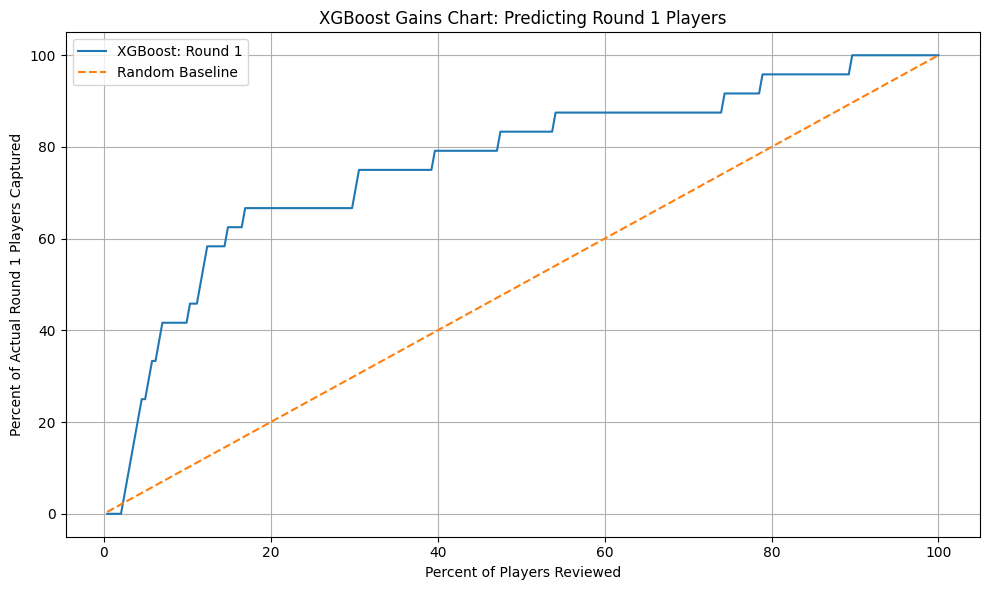


Creating XGBoost gains chart for: Rounds 2-3


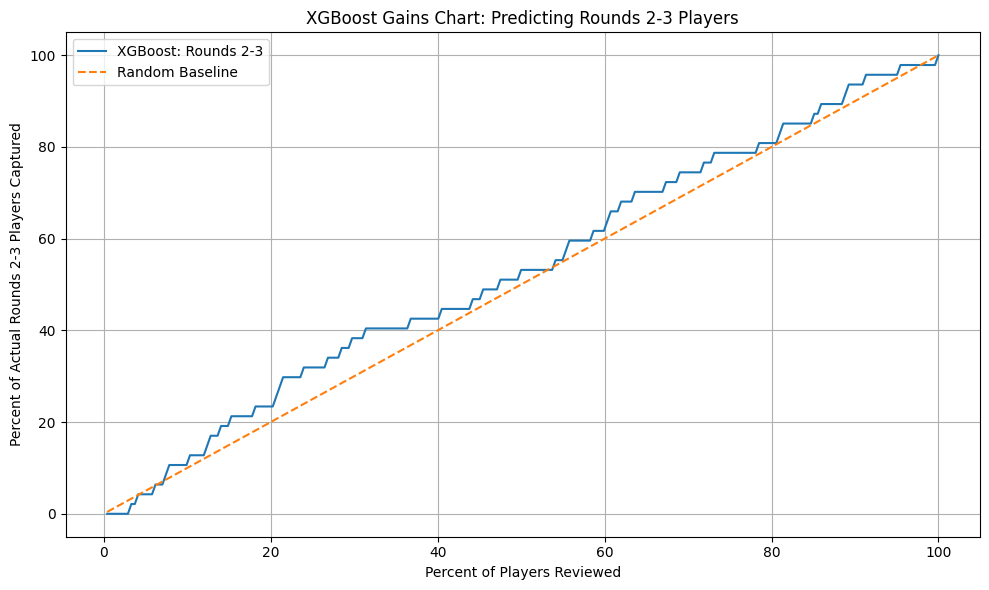


Creating XGBoost gains chart for: Rounds 4-5


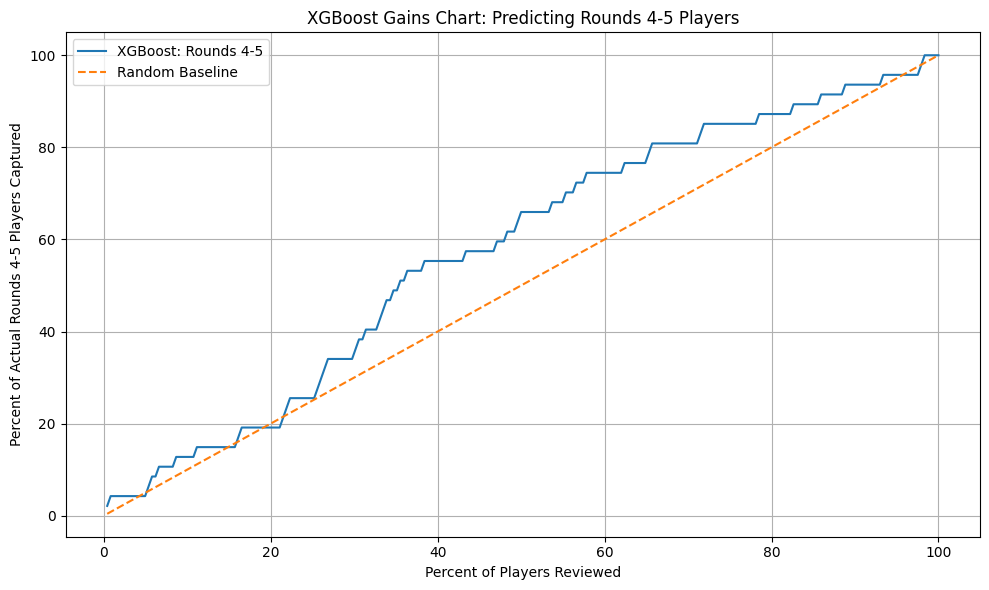


Creating XGBoost gains chart for: Rounds 6-7


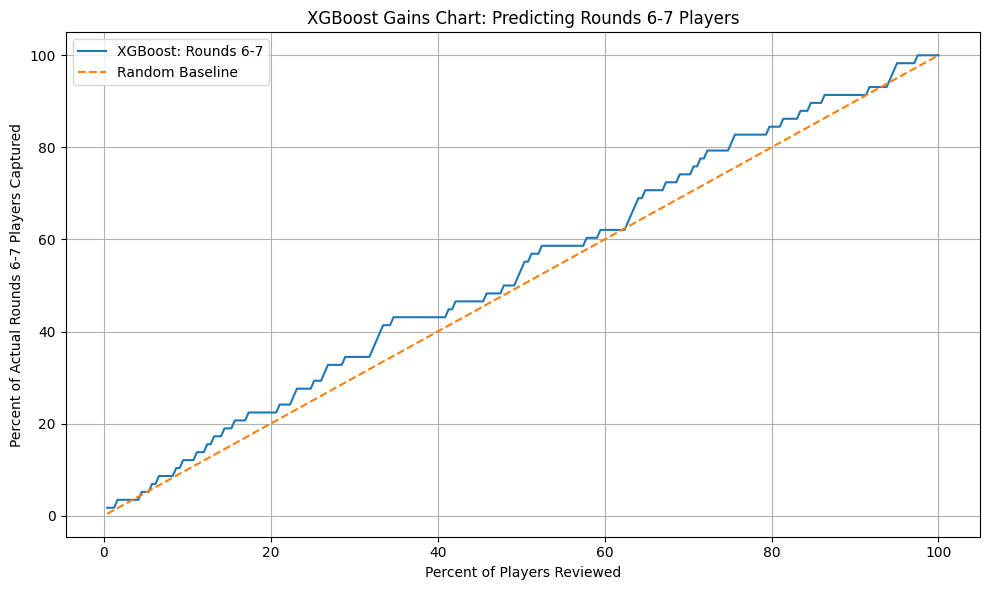


Creating XGBoost gains chart for: Undrafted


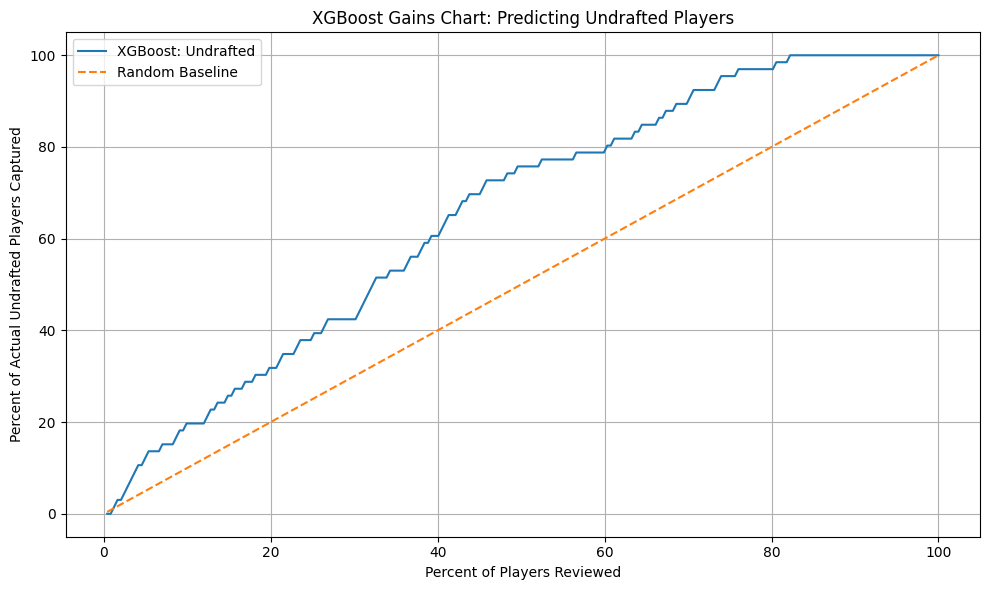


Done. XGBoost model, feature importance, predictions, and gains charts saved.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT TIER TARGET
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]


# =========================
# 5. ENCODE TARGET FOR XGBOOST
# =========================

label_encoder = LabelEncoder()
df["Draft Tier Encoded"] = label_encoder.fit_transform(df["Draft Tier"])

print("\nEncoded Class Order:")
for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(label, "=", code)


# =========================
# 6. BUILD XGBOOST MODEL FUNCTION
# =========================

def build_xgboost_model(feature_list):

    categorical_features = [
        col for col in ["Position", "Position Group", "School", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                objective="multi:softprob",
                num_class=5,
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="mlogloss"
            ))
        ]
    )

    return model


# =========================
# 7. MANUAL CLASSIFICATION REPORT
# =========================

def print_manual_report(y_true_labels, y_pred_labels, title):

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_labels,
        y_pred_labels,
        labels=labels_order,
        zero_division=0
    )

    print(f"\n{title}")
    print(f"{'Class':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    print("\nAccuracy:", round(accuracy_score(y_true_labels, y_pred_labels), 4))


# =========================
# 8. OVERALL XGBOOST MODEL
# =========================

X = df[features]
y = df["Draft Tier Encoded"]

overall_model = build_xgboost_model(features)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    overall_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nOVERALL XGBOOST MODEL - 5-Fold CV Accuracy Scores:")
print(cv_scores)
print("Average CV Accuracy:", round(cv_scores.mean(), 4))
print("CV Accuracy Standard Deviation:", round(cv_scores.std(), 4))


# =========================
# 9. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

overall_model.fit(X_train, y_train)

y_pred = overall_model.predict(X_test)

y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print_manual_report(
    y_test_labels,
    y_pred_labels,
    "OVERALL XGBOOST MODEL - Classification Report"
)


# =========================
# 10. XGBOOST FEATURE IMPORTANCE
# =========================

xgb = overall_model.named_steps["classifier"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Overall XGBoost Features:")
print(importance_df.head(20).to_string(index=False))

importance_df.to_csv(
    "xgboost_feature_importance_no_log_rank.csv",
    index=False
)


# =========================
# 11. GAINS CHARTS FOR OVERALL XGBOOST MODEL
# =========================

predicted_probs = overall_model.predict_proba(X_test)

class_codes = overall_model.named_steps["classifier"].classes_
class_labels = label_encoder.inverse_transform(class_codes)

prob_df = pd.DataFrame(
    predicted_probs,
    columns=class_labels
)

gains_base = X_test.copy().reset_index(drop=True)
gains_base["Actual Draft Tier"] = pd.Series(y_test_labels).reset_index(drop=True)


def plot_gains_chart(target_tier):

    temp_df = gains_base.copy()

    temp_df["Actual Target"] = np.where(
        temp_df["Actual Draft Tier"] == target_tier,
        1,
        0
    )

    temp_df["Predicted Probability"] = prob_df[target_tier].values

    temp_df = temp_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    total_actual_targets = temp_df["Actual Target"].sum()

    if total_actual_targets == 0:
        print(f"No actual {target_tier} players in the test set.")
        return None

    temp_df["Cumulative Actual Captured"] = temp_df["Actual Target"].cumsum()

    temp_df["Percent of Players Reviewed"] = (
        np.arange(1, len(temp_df) + 1) / len(temp_df)
    ) * 100

    temp_df["Percent of Actual Tier Captured"] = (
        temp_df["Cumulative Actual Captured"] / total_actual_targets
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Actual Tier Captured"],
        label=f"XGBoost: {target_tier}"
    )

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"XGBoost Gains Chart: Predicting {target_tier} Players")
    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_tier} Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return temp_df


tier_outputs = {}

for tier in labels_order:
    print(f"\nCreating XGBoost gains chart for: {tier}")
    tier_outputs[tier] = plot_gains_chart(tier)


# =========================
# 12. SAVE GAINS CHART OUTPUTS
# =========================

for tier, output_df in tier_outputs.items():
    if output_df is not None:
        clean_name = (
            tier.replace(" ", "_")
                .replace("-", "_")
                .replace("/", "_")
        )

        output_df.to_csv(
            f"xgboost_gains_chart_{clean_name}_no_log_rank.csv",
            index=False
        )


# =========================
# 13. SAVE PREDICTIONS
# =========================

results_df = X_test.copy()
results_df["Actual Draft Tier"] = y_test_labels
results_df["Predicted Draft Tier"] = y_pred_labels

results_df.to_csv(
    "xgboost_overall_predictions_no_log_rank.csv",
    index=False
)

print("\nDone. XGBoost model, feature importance, predictions, and gains charts saved.")